# Transport Emissions in Australia — Analysis

Runs the same functions as `run_pipeline.py`, and also displays every chart inline in this notebook. Each figure still saves to `reports/` too, same as a normal pipeline run — this notebook doesn't change that, it just additionally shows you the result right here.

**If you've just updated eda.py / model.py / validate.py, restart the kernel before running this** — editing a `.py` file doesn't reload it in an already-running kernel.

In [1]:
# Find the repo root (the folder containing run_pipeline.py), wherever
# Jupyter's working directory happens to be, then import the pipeline modules.
import sys
import io
from pathlib import Path
from IPython.display import display, Image

p = Path.cwd()
while not (p / "run_pipeline.py").exists() and p != p.parent:
    p = p.parent
REPO_ROOT = p
sys.path.insert(0, str(REPO_ROOT))
print("Repo root:", REPO_ROOT)

from src.analysis import clean, eda, model, validate


def show(fig):
    """Display a matplotlib Figure inline. The pipeline modules force
    the non-interactive 'Agg' backend (so run_pipeline.py can run
    headless in CI), which doesn't auto-render in a notebook the way
    the default 'inline' backend does -- so this renders the figure to
    PNG bytes in memory and displays those directly, which works
    regardless of backend."""
    buf = io.BytesIO()
    fig.savefig(buf, format="png", dpi=100, bbox_inches="tight")
    buf.seek(0)
    display(Image(buf.read()))

Repo root: /Users/susan/Desktop/CDU/2026 sem 2/untitled folder/Data_Practice_Project/Branch-UB


## Load data

Builds the processed tables if they don't already exist (same as the pipeline's Step 1), then loads them.

In [2]:
annual, annual_pop, monthly_fuel = eda._load_processed()
print(f"annual_master: {len(annual)} rows, states = {sorted(annual['state'].unique())}, "
      f"years {annual['year'].min()}-{annual['year'].max()}")
annual.head()

annual_master: 98 rows, states = ['NSW', 'NT', 'QLD', 'SA', 'TAS', 'VIC', 'WA'], years 2010-2023


,state,year,fuel_consumption_ml,vkt_road_million_km,ghg_kt_co2e,registered_vehicles
0,NSW,2010,10717.5,70335.567059,26409.641452,6407861
1,NSW,2011,10763.3,71054.120965,26290.331005,6407861
2,NSW,2012,11073.4,72635.877810,26627.942130,6407861
3,NSW,2013,11371.0,73821.042207,26257.396715,6407861
4,NSW,2014,11340.5,75005.923965,27074.993487,6407861


## Exploratory Data Analysis

INFO: Saved /Users/susan/Desktop/CDU/2026 sem 2/untitled folder/Data_Practice_Project/Branch-UB/reports/figures/01_distributions.png


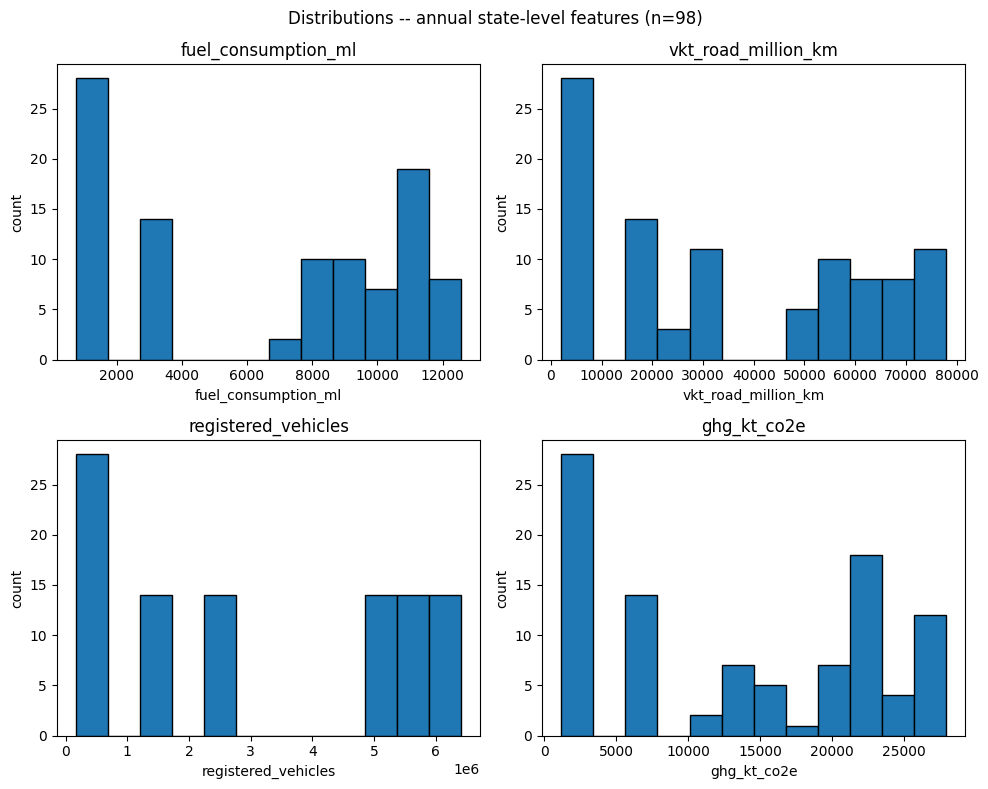

In [3]:
show(eda.plot_distributions(annual))

INFO: Saved /Users/susan/Desktop/CDU/2026 sem 2/untitled folder/Data_Practice_Project/Branch-UB/reports/figures/02_emissions_trend_by_state.png


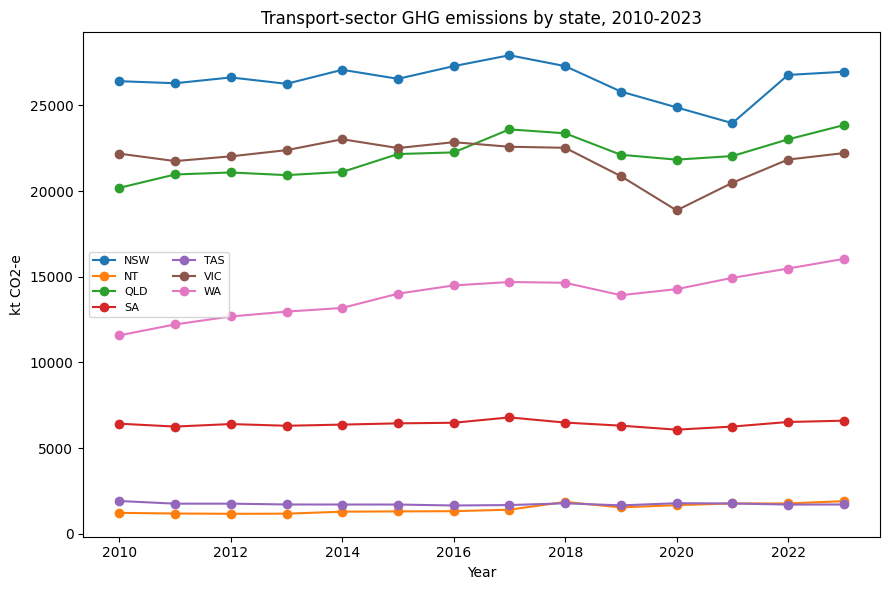

In [4]:
show(eda.plot_state_trends(annual))

INFO: Saved /Users/susan/Desktop/CDU/2026 sem 2/untitled folder/Data_Practice_Project/Branch-UB/reports/figures/03_correlation_heatmap.png


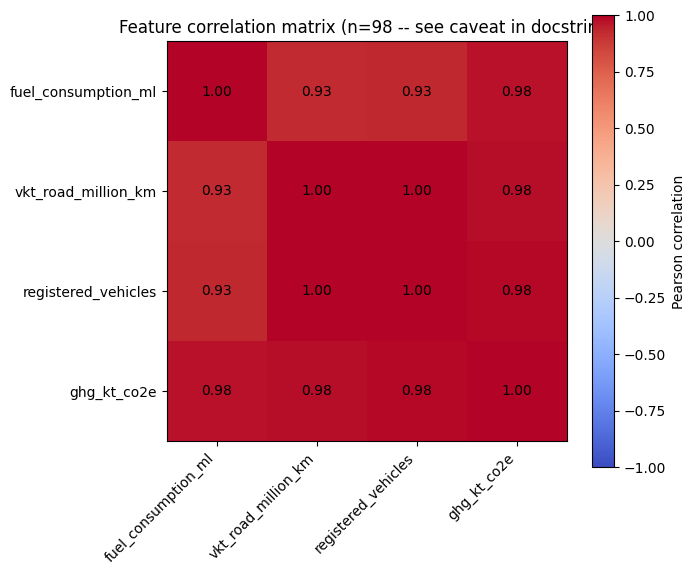

In [5]:
show(eda.plot_correlation_heatmap(annual))

INFO: Saved /Users/susan/Desktop/CDU/2026 sem 2/untitled folder/Data_Practice_Project/Branch-UB/reports/figures/04_monthly_fuel_by_state.png


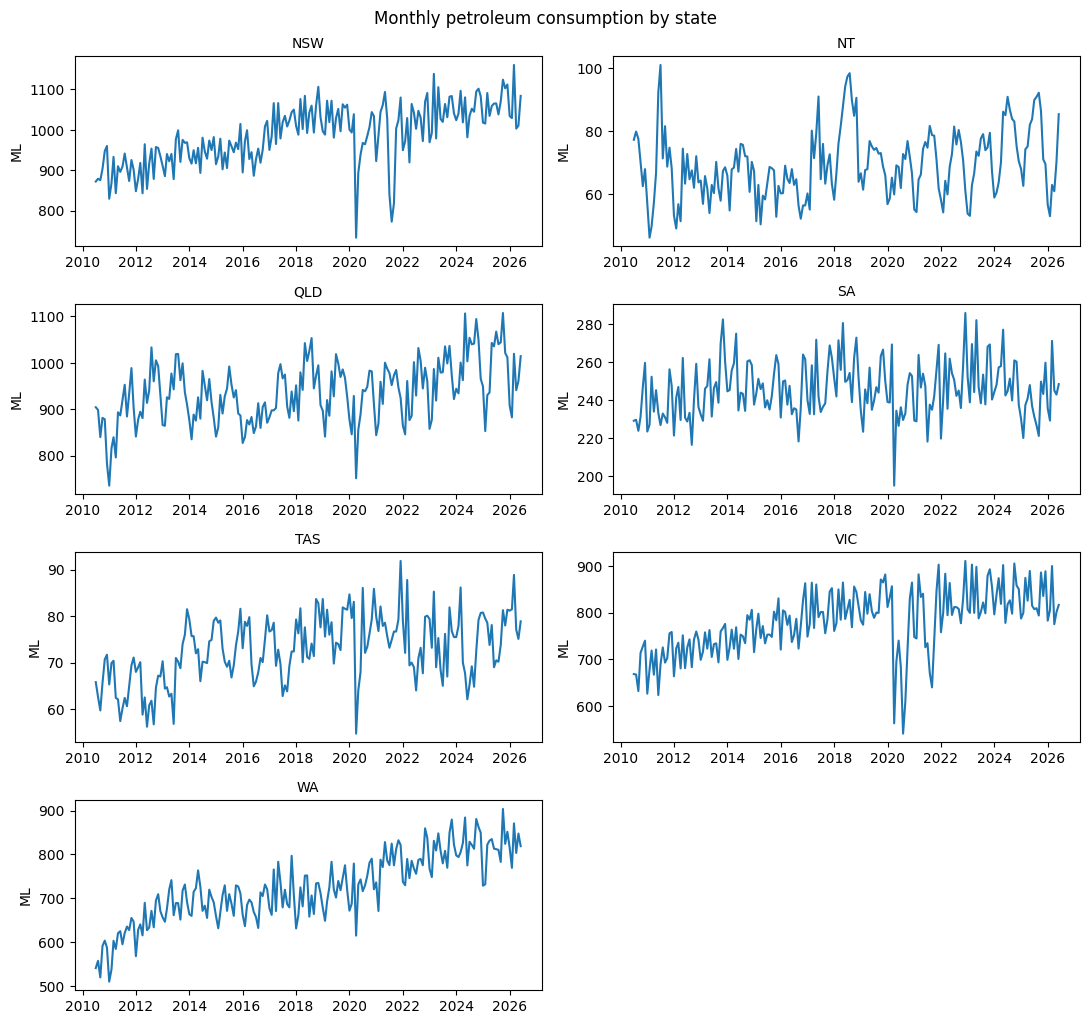

In [6]:
show(eda.plot_monthly_fuel_series(monthly_fuel))

INFO: Saved /Users/susan/Desktop/CDU/2026 sem 2/untitled folder/Data_Practice_Project/Branch-UB/reports/figures/05_per_capita_scatter.png


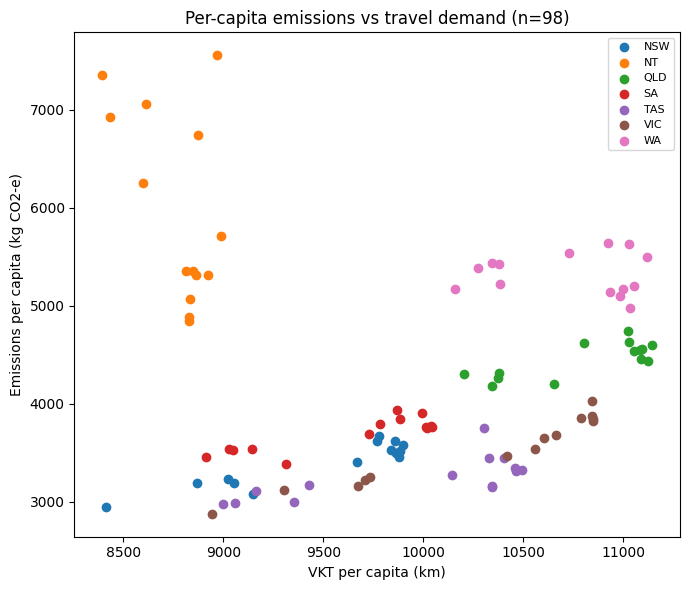

In [7]:
show(eda.plot_per_capita(annual_pop))

## Model 1 — Emissions Regression

Predicts annual state transport-sector emissions from fuel, VKT, and vehicle count. CV R² close to 1 is expected here (see `model.py`'s docstring) — emissions are calculated from fuel via published factors, so this is close to rediscovering that formula, not a hard predictive win.

In [8]:
model.fit_emissions_regression()

INFO: linear_regression -- CV R2=0.995, CV MAE=497.1 kt CO2-e
INFO: random_forest -- CV R2=0.995, CV MAE=457.7 kt CO2-e
INFO: Random forest feature importances: {'fuel_consumption_ml': np.float64(0.4005), 'vkt_road_million_km': np.float64(0.4784), 'registered_vehicles': np.float64(0.1211)}


{'linear_regression': {'cv_r2': 0.9949, 'cv_mae_kt_co2e': 497.1},
 'random_forest': {'cv_r2': 0.9949,
  'cv_mae_kt_co2e': 457.66,
  'feature_importance': {'fuel_consumption_ml': np.float64(0.4005),
   'vkt_road_million_km': np.float64(0.4784),
   'registered_vehicles': np.float64(0.1211)}},
 '_caveat': "n=98. Whether this reflects real or synthetic fixture data depends on this run's sources -- check the 'Using real data' / 'Using sample data' / 'Falling back to fixture' log lines clean.py printed during Step 1 of this pipeline run before citing this number."}

## Model 2 — Fuel Consumption Forecast (every state)

This is the genuinely predictive result — forecasting each state's future fuel demand from its own history.

/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
INFO: Saved /Users/susan/Desktop/CDU/2026 sem 2/untitled folder/Data_Practice_Project/Branch-UB/reports/figures/06_forecast_NSW.png
INFO: Forecast (NSW, holt_winters): MAE=40.0 ML, MAPE=3.8%


NSW: MAPE=3.84%  MAE=40.02 ML  method=holt_winters


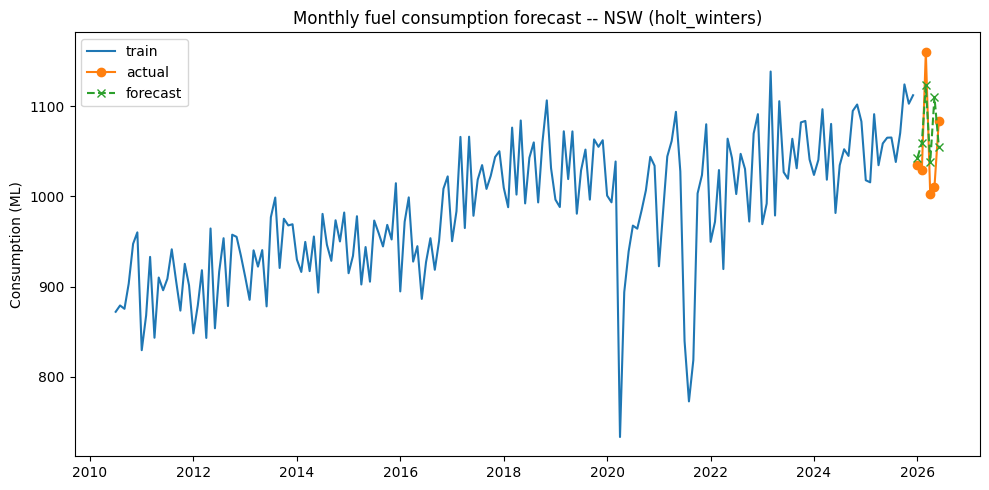

/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
INFO: Saved /Users/susan/Desktop/CDU/2026 sem 2/untitled folder/Data_Practice_Project/Branch-UB/reports/figures/06_forecast_NT.png
INFO: Forecast (NT, holt_winters): MAE=8.0 ML, MAPE=12.9%


NT: MAPE=12.92%  MAE=7.97 ML  method=holt_winters


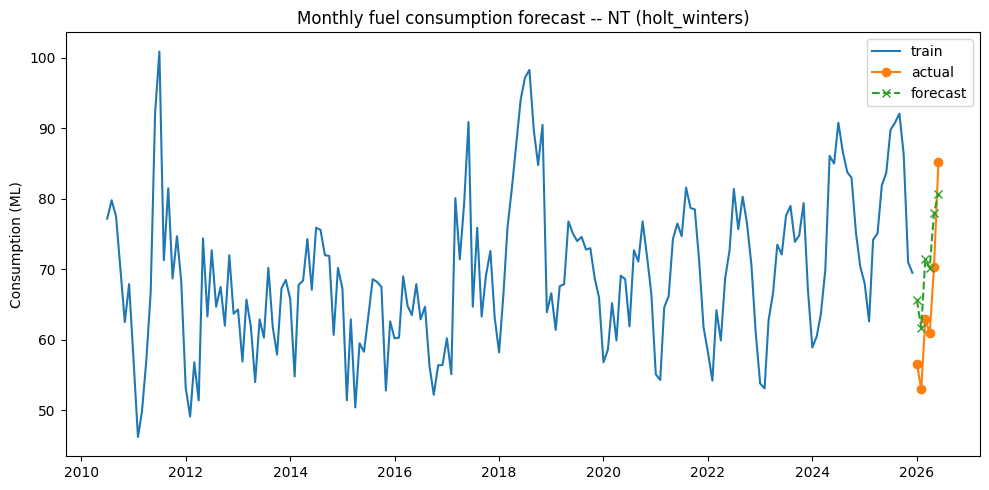

/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
INFO: Saved /Users/susan/Desktop/CDU/2026 sem 2/untitled folder/Data_Practice_Project/Branch-UB/reports/figures/06_forecast_QLD.png
INFO: Forecast (QLD, holt_winters): MAE=53.0 ML, MAPE=5.7%


QLD: MAPE=5.67%  MAE=53.0 ML  method=holt_winters


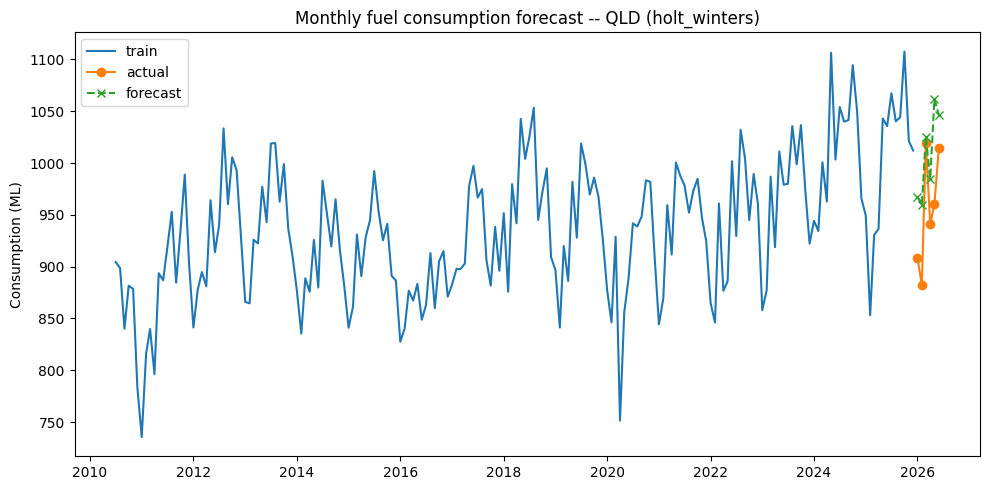

/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
INFO: Saved /Users/susan/Desktop/CDU/2026 sem 2/untitled folder/Data_Practice_Project/Branch-UB/reports/figures/06_forecast_SA.png
INFO: Forecast (SA, holt_winters): MAE=11.4 ML, MAPE=4.5%


SA: MAPE=4.53%  MAE=11.42 ML  method=holt_winters


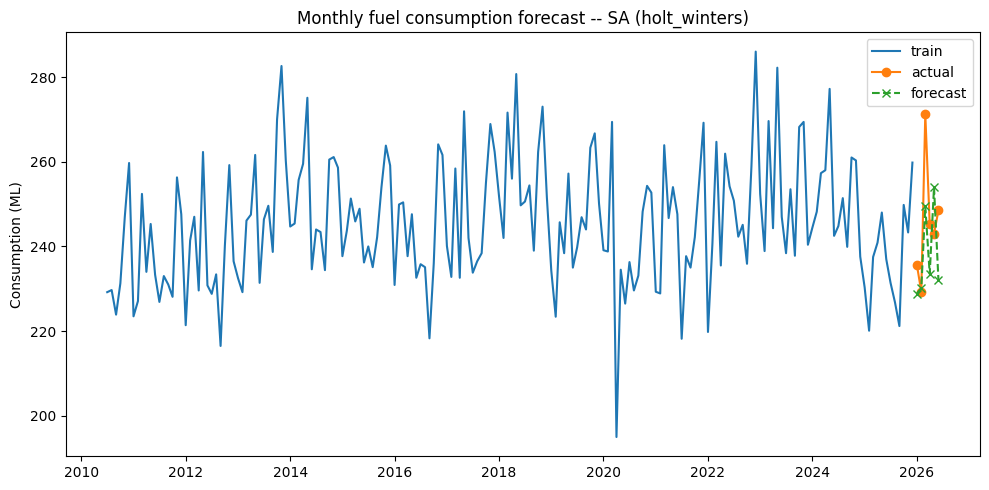

/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
INFO: Saved /Users/susan/Desktop/CDU/2026 sem 2/untitled folder/Data_Practice_Project/Branch-UB/reports/figures/06_forecast_TAS.png
INFO: Forecast (TAS, holt_winters): MAE=3.8 ML, MAPE=4.7%


TAS: MAPE=4.71%  MAE=3.83 ML  method=holt_winters


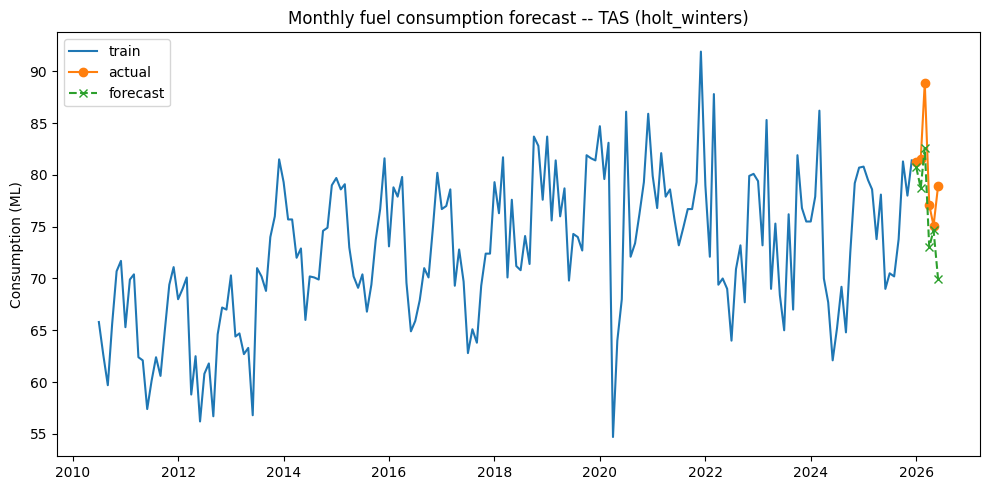

/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
INFO: Saved /Users/susan/Desktop/CDU/2026 sem 2/untitled folder/Data_Practice_Project/Branch-UB/reports/figures/06_forecast_VIC.png
INFO: Forecast (VIC, holt_winters): MAE=27.8 ML, MAPE=3.5%


VIC: MAPE=3.45%  MAE=27.84 ML  method=holt_winters


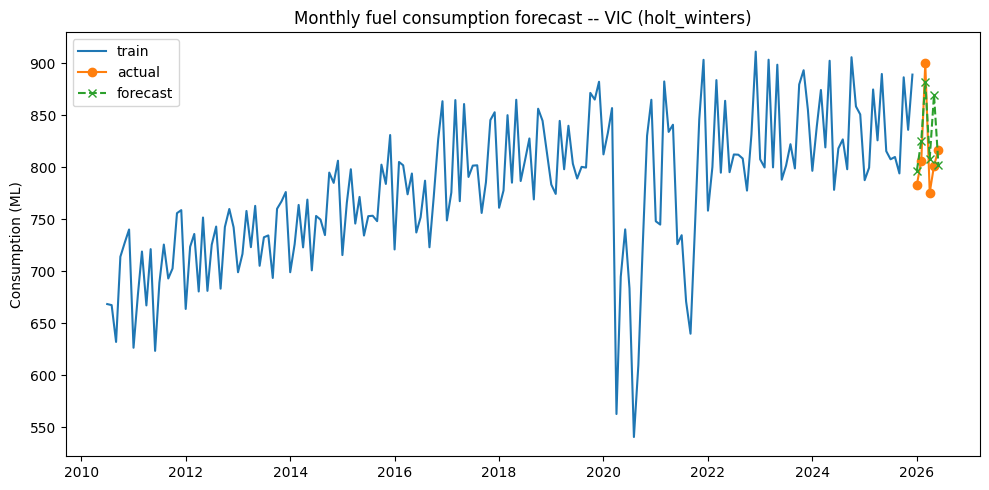

/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
INFO: Saved /Users/susan/Desktop/CDU/2026 sem 2/untitled folder/Data_Practice_Project/Branch-UB/reports/figures/06_forecast_WA.png
INFO: Forecast (WA, holt_winters): MAE=22.4 ML, MAPE=2.7%


WA: MAPE=2.71%  MAE=22.43 ML  method=holt_winters


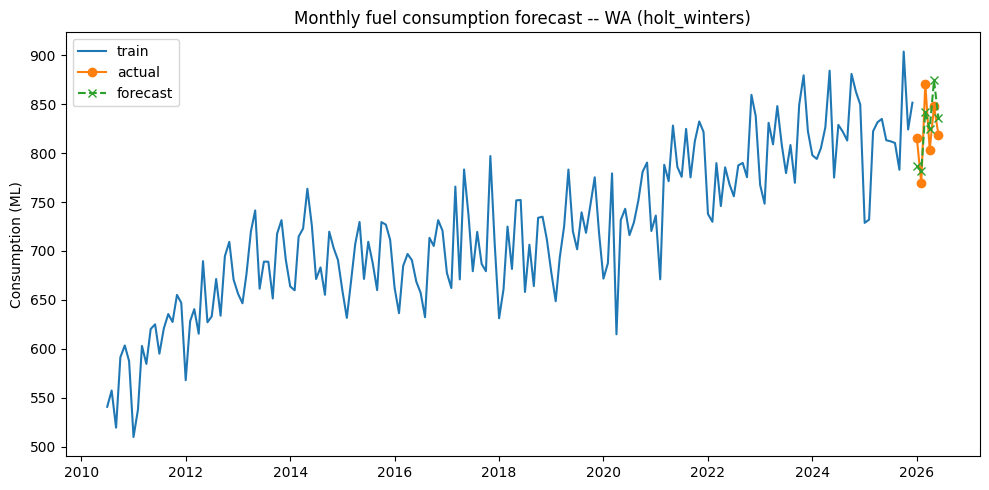

In [9]:
for state in sorted(monthly_fuel["state"].unique()):
    result = model.forecast_fuel_consumption(state)
    fig = result.pop("_figure")
    print(f"{state}: MAPE={result['mape_pct']}%  MAE={result['mae_ml']} ML  method={result['method']}")
    show(fig)

In [10]:
import inspect
print(inspect.getsource(eda.plot_distributions))

def plot_distributions(annual: pd.DataFrame, save: bool = True) -> plt.Figure:
    """Histogram of each numeric feature and the target."""
    cols = FEATURE_COLS + [TARGET_COL]
    fig, axes = plt.subplots(2, 2, figsize=(10, 8))
    for ax, col in zip(axes.flat, cols):
        ax.hist(annual[col], bins=12, edgecolor="black")
        ax.set_title(col)
        ax.set_xlabel(col)
        ax.set_ylabel("count")
    fig.suptitle(f"Distributions -- annual state-level features (n={len(annual)})")
    fig.tight_layout()
    if save:
        out = FIGURES_DIR / "01_distributions.png"
        fig.savefig(out, dpi=150)
        log.info("Saved %s", out)
    return fig



## Data Quality Validation

Checks whether (fuel × published emission factor) is consistent with the reported transport-sector emissions figure. See `validate.py`'s docstring for why a moderate gap is expected, not a bug.

In [11]:
comparison, fig = validate.validate_emission_factors()
print(f"n={len(comparison)} state-years, mean % difference = {comparison['pct_diff'].mean():.1f}%")
comparison

INFO: Using real data for 'petroleum_statistics': /Users/susan/Desktop/CDU/2026 sem 2/untitled folder/Data_Practice_Project/Branch-UB/data/bronze/Australian Petroleum statistics consumption cover/australian_petroleum_statistics_-_data_extract_june_2026.xlsx
INFO: Using real data for 'nga_factors_2025': /Users/susan/Desktop/CDU/2026 sem 2/untitled folder/Data_Practice_Project/Branch-UB/data/bronze/Australian National Greenhouse Accounts Factors/national-greenhouse-account-factors-2025.xlsx
INFO: Using real data for 'state_territory_ghg': /Users/susan/Desktop/CDU/2026 sem 2/untitled folder/Data_Practice_Project/Branch-UB/data/bronze/State & Territory Inventories 2024 - Emission Data Tables/state-territory-inventories-2024-emission-data-tables.xlsx
INFO: Emission factor check: implied road-fuel emissions run 29.7% below reported whole-transport-sector emissions on average (n=98 state-years). This is expected, not necessarily an error -- see this function's docstring: reported figures incl

n=98 state-years, mean % difference = 29.7%


,state,year,implied_kt_co2e,ghg_kt_co2e,abs_diff_kt,pct_diff
0,NSW,2010,26660.660264,26409.641452,251.018812,0.950482
1,NSW,2011,26854.753834,26290.331005,564.422829,2.146884
2,NSW,2012,27710.154081,26627.942130,1082.211951,4.064197
3,NSW,2013,28520.599987,26257.396715,2263.203271,8.619298
4,NSW,2014,28458.737315,27074.993487,1383.743828,5.110782
...,...,...,...,...,...,...
93,WA,2019,22764.179295,13924.384069,8839.795226,63.484282
94,WA,2020,23932.578106,14278.089286,9654.488820,67.617513
95,WA,2021,24837.729280,14934.532588,9903.196692,66.310724
96,WA,2022,25419.291904,15480.083249,9939.208655,64.206429


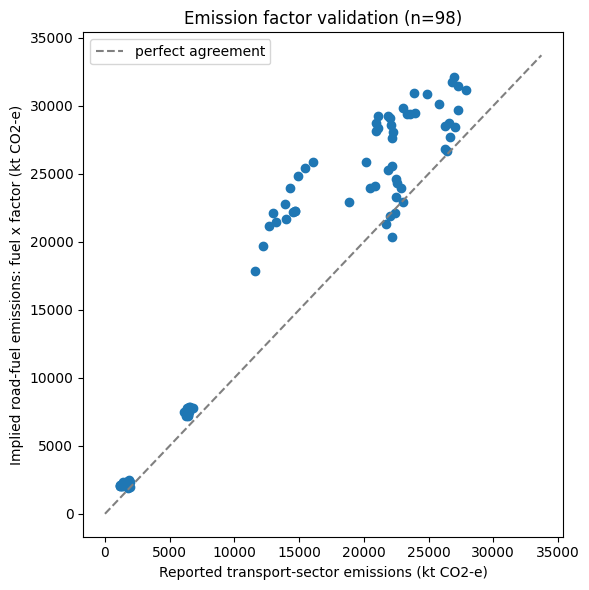

In [12]:
show(fig)